# VQE Default Calibration

This notebook is for choosing **robust VQE defaults**, not one-off best-case settings.

It sweeps a compact grid over:

- ansatz choice
- optimizer choice
- stepsize
- total step budget
- random seed

and compares results against the exact qubit-Hamiltonian ground energy.

Use the final recommendation table to decide whether `run_vqe(...)` defaults should change.

## How To Use This Notebook

- Treat the grids in the next cell as the only inputs you should edit.
- Keep at least two molecules and multiple seeds when deciding repo defaults.
- Prefer settings that are robust across molecules before preferring tiny final-energy improvements on one system.
- Use the final `recommended_defaults` table as the candidate source for code-default updates.


In [1]:
from __future__ import annotations

import time
from contextlib import redirect_stdout
from io import StringIO
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from common.hamiltonian import build_hamiltonian
from vqe import run_vqe, OPTIMIZERS, ANSATZES

MOLECULE_SPECS = [
    {"molecule": "H2", "mapping": "jordan_wigner"},
    {
        "molecule": "LiH",
        "mapping": "jordan_wigner",
        "active_electrons": 2,
        "active_orbitals": 2,
    },
]

STEPSIZES = [0.1, 0.2]
STEP_BUDGETS = [75]
SEEDS = [0]


def timed_call(fn, /, **kwargs):
    t0 = time.perf_counter()
    sink = StringIO()
    with redirect_stdout(sink):
        result = fn(**kwargs)
    return result, time.perf_counter() - t0


def exact_ground(spec):
    H, _, _ = build_hamiltonian(**spec)
    mat = np.asarray(qml.matrix(H), dtype=complex)
    return float(np.min(np.linalg.eigvalsh(mat)).real)


def stats(xs):
    arr = np.asarray(xs, dtype=float)
    return {
        "mean": float(arr.mean()),
        "std": float(arr.std(ddof=0)),
        "min": float(arr.min()),
        "max": float(arr.max()),
    }


EXACT = {spec["molecule"]: exact_ground(spec) for spec in MOLECULE_SPECS}
EXACT
TOTAL_RUNS = (
    len(MOLECULE_SPECS)
    * len(ANSATZES)
    * len(OPTIMIZERS)
    * len(STEPSIZES)
    * len(STEP_BUDGETS)
    * len(SEEDS)
)


In [2]:
records = []
run_index = 0


for spec in MOLECULE_SPECS:
    shared = dict(spec)
    molecule = shared["molecule"]
    exact_e0 = EXACT[molecule]

    for ansatz in ANSATZES:
        for optimizer in OPTIMIZERS:
            for stepsize in STEPSIZES:
                for steps in STEP_BUDGETS:
                    for seed in SEEDS:
                        run_index += 1
                        print(
                            f"[{run_index}/{TOTAL_RUNS}] "
                            f"{molecule} | ansatz={ansatz} | opt={optimizer} | "
                            f"stepsize={stepsize} | steps={steps} | seed={seed}"
                        )
                        result, runtime_s = timed_call(
                            run_vqe,
                            **shared,
                            ansatz_name=ansatz,
                            optimizer_name=optimizer,
                            steps=steps,
                            stepsize=stepsize,
                            seed=seed,
                            noisy=False,
                            plot=False,
                            force=False,
                        )
                        records.append(
                            {
                                "molecule": molecule,
                                "ansatz": ansatz,
                                "optimizer": optimizer,
                                "stepsize": float(stepsize),
                                "steps": int(steps),
                                "seed": int(seed),
                                "energy": float(result["energy"]),
                                "abs_error": abs(float(result["energy"]) - exact_e0),
                                "runtime_s": float(runtime_s),
                                "num_qubits": int(result["num_qubits"]),
                                "param_count": int(np.asarray(result["final_params"]).size),
                            }
                        )

len(records)

[1/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=Adam | stepsize=0.1 | steps=75 | seed=0
[2/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=Adam | stepsize=0.2 | steps=75 | seed=0
[3/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=GradientDescent | stepsize=0.1 | steps=75 | seed=0
[4/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=GradientDescent | stepsize=0.2 | steps=75 | seed=0
[5/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=Momentum | stepsize=0.1 | steps=75 | seed=0
[6/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=Momentum | stepsize=0.2 | steps=75 | seed=0
[7/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=NesterovMomentum | stepsize=0.1 | steps=75 | seed=0
[8/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=NesterovMomentum | stepsize=0.2 | steps=75 | seed=0
[9/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=RMSProp | stepsize=0.1 | steps=75 | seed=0
[10/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=RMSProp | stepsize=0.2 | steps=75 | seed=0
[11/168] H2 | ansatz=TwoQubit-RY-CNOT | opt=Adagrad | stepsize=0.1 | steps=75 | seed=0
[12/168] H2 | ansatz=T

168

In [3]:
grouped = defaultdict(list)
for row in records:
    key = (
        row["molecule"],
        row["ansatz"],
        row["optimizer"],
        row["stepsize"],
        row["steps"],
    )
    grouped[key].append(row)

summary = []
for key, rows in sorted(grouped.items()):
    energies = [r["energy"] for r in rows]
    errors = [r["abs_error"] for r in rows]
    runtimes = [r["runtime_s"] for r in rows]
    summary.append(
        {
            "molecule": key[0],
            "ansatz": key[1],
            "optimizer": key[2],
            "stepsize": key[3],
            "steps": key[4],
            "mean_abs_error": stats(errors)["mean"],
            "std_abs_error": stats(errors)["std"],
            "mean_energy": stats(energies)["mean"],
            "mean_runtime_s": stats(runtimes)["mean"],
            "score": stats(errors)["mean"] + 0.25 * stats(errors)["std"] + 0.001 * stats(runtimes)["mean"],
        }
    )

summary[:10]

[{'molecule': 'H2',
  'ansatz': 'Minimal',
  'optimizer': 'Adagrad',
  'stepsize': 0.1,
  'steps': 75,
  'mean_abs_error': 0.49095551141352967,
  'std_abs_error': 0.0,
  'mean_energy': -0.6463146634706455,
  'mean_runtime_s': 0.04421087700029602,
  'score': 0.49099972229052996},
 {'molecule': 'H2',
  'ansatz': 'Minimal',
  'optimizer': 'Adagrad',
  'stepsize': 0.2,
  'steps': 75,
  'mean_abs_error': 0.02827377498541761,
  'std_abs_error': 0.0,
  'mean_energy': -1.1089963998987575,
  'mean_runtime_s': 0.04897127900039777,
  'score': 0.028322746264418008},
 {'molecule': 'H2',
  'ansatz': 'Minimal',
  'optimizer': 'Adam',
  'stepsize': 0.1,
  'steps': 75,
  'mean_abs_error': 0.0215113349685061,
  'std_abs_error': 0.0,
  'mean_energy': -1.115758839915669,
  'mean_runtime_s': 0.03900413299925276,
  'score': 0.021550339101505354},
 {'molecule': 'H2',
  'ansatz': 'Minimal',
  'optimizer': 'Adam',
  'stepsize': 0.2,
  'steps': 75,
  'mean_abs_error': 0.021171507482976137,
  'std_abs_error': 0.

In [4]:
best_per_molecule = {}
for molecule in sorted({row["molecule"] for row in summary}):
    rows = [row for row in summary if row["molecule"] == molecule]
    rows = sorted(rows, key=lambda row: (row["score"], row["mean_abs_error"], row["mean_runtime_s"]))
    best_per_molecule[molecule] = rows[:10]

best_per_molecule

{'H2': [{'molecule': 'H2',
   'ansatz': 'UCCD',
   'optimizer': 'Adagrad',
   'stepsize': 0.2,
   'steps': 75,
   'mean_abs_error': 0.0,
   'std_abs_error': 0.0,
   'mean_energy': -1.1372701748841751,
   'mean_runtime_s': 0.03440887000033399,
   'score': 3.440887000033399e-05},
  {'molecule': 'H2',
   'ansatz': 'UCCSD',
   'optimizer': 'Adagrad',
   'stepsize': 0.2,
   'steps': 75,
   'mean_abs_error': 0.0,
   'std_abs_error': 0.0,
   'mean_energy': -1.1372701748841751,
   'mean_runtime_s': 0.03493695299766841,
   'score': 3.4936952997668416e-05},
  {'molecule': 'H2',
   'ansatz': 'UCCSD',
   'optimizer': 'GradientDescent',
   'stepsize': 0.1,
   'steps': 75,
   'mean_abs_error': 7.951371050474165e-08,
   'std_abs_error': 0.0,
   'mean_energy': -1.1372700953704646,
   'mean_runtime_s': 0.03530160199807142,
   'score': 3.538111570857616e-05},
  {'molecule': 'H2',
   'ansatz': 'UCCD',
   'optimizer': 'GradientDescent',
   'stepsize': 0.1,
   'steps': 75,
   'mean_abs_error': 7.9513710504

## How To Interpret The Results

- `best_per_molecule` shows the strongest settings for each benchmark molecule.
- `recommended_defaults` intentionally aggregates only the chemistry-baseline ansatz (`UCCSD`) so the final recommendation stays realistic for the package defaults.
- The notebook score favors low absolute error first, then stability across seeds, then runtime.


In [5]:
recommended_defaults = []
candidate_rows = [row for row in summary if row["ansatz"] == "UCCSD"]
if candidate_rows:
    by_setting = defaultdict(list)
    for row in candidate_rows:
        by_setting[(row["optimizer"], row["stepsize"], row["steps"])].append(row)

    aggregate = []
    for key, rows in sorted(by_setting.items()):
        aggregate.append(
            {
                "optimizer": key[0],
                "stepsize": key[1],
                "steps": key[2],
                "mean_abs_error": float(np.mean([row["mean_abs_error"] for row in rows])),
                "mean_std_abs_error": float(np.mean([row["std_abs_error"] for row in rows])),
                "mean_runtime_s": float(np.mean([row["mean_runtime_s"] for row in rows])),
            }
        )
    aggregate = sorted(
        aggregate,
        key=lambda row: (row["mean_abs_error"] + 0.25 * row["mean_std_abs_error"] + 0.001 * row["mean_runtime_s"], row["mean_abs_error"]),
    )
    recommended_defaults = aggregate[:10]

recommended_defaults

[{'optimizer': 'Adam',
  'stepsize': 0.2,
  'steps': 75,
  'mean_abs_error': 2.033588290428767e-06,
  'mean_std_abs_error': 0.0,
  'mean_runtime_s': 0.5632020789998933},
 {'optimizer': 'NesterovMomentum',
  'stepsize': 0.1,
  'steps': 75,
  'mean_abs_error': 5.507322931030956e-09,
  'mean_std_abs_error': 0.0,
  'mean_runtime_s': 1.918337719500414},
 {'optimizer': 'GradientDescent',
  'stepsize': 0.2,
  'steps': 75,
  'mean_abs_error': 1.205480120503033e-06,
  'mean_std_abs_error': 0.0,
  'mean_runtime_s': 2.0553019100025267},
 {'optimizer': 'Adam',
  'stepsize': 0.1,
  'steps': 75,
  'mean_abs_error': 1.9061289087130007e-06,
  'mean_std_abs_error': 0.0,
  'mean_runtime_s': 2.08521432049929},
 {'optimizer': 'Momentum',
  'stepsize': 0.2,
  'steps': 75,
  'mean_abs_error': 1.961668833039276e-06,
  'mean_std_abs_error': 0.0,
  'mean_runtime_s': 2.098926439999559},
 {'optimizer': 'Adagrad',
  'stepsize': 0.2,
  'steps': 75,
  'mean_abs_error': 1.7763568394002505e-15,
  'mean_std_abs_error'

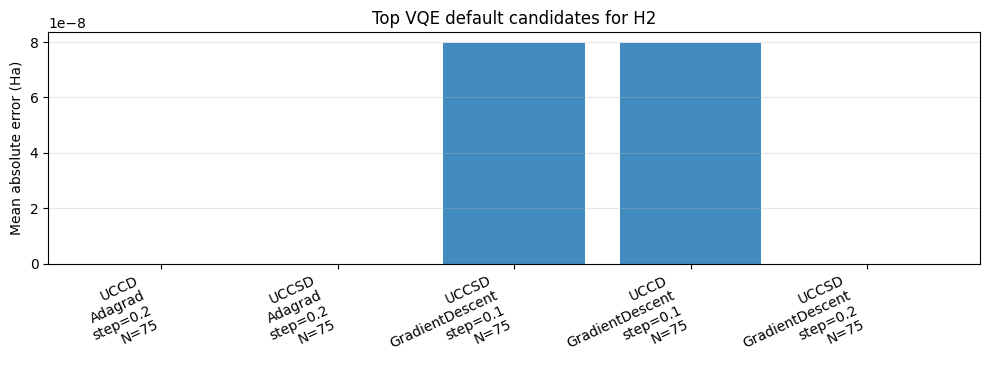

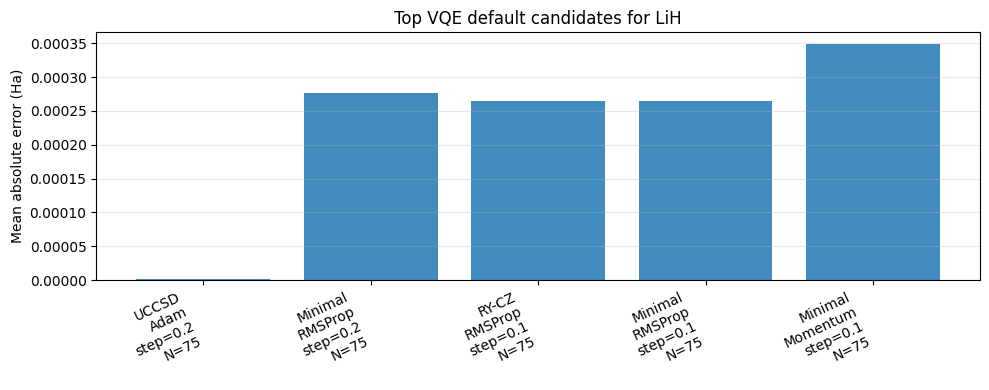

In [6]:
for molecule in sorted(best_per_molecule):
    rows = best_per_molecule[molecule][:5]
    labels = [f"{row['ansatz']}\n{row['optimizer']}\nstep={row['stepsize']}\nN={row['steps']}" for row in rows]
    values = [row["mean_abs_error"] for row in rows]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values, alpha=0.85)
    plt.ylabel("Mean absolute error (Ha)")
    plt.title(f"Top VQE default candidates for {molecule}")
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()